# Test (a) - Starring into water

With this test we wanted to investigate, if the retrieved lidar-water range is constant and independent of the range gate length $L_{\rm rg}$.
We found, this is not the case and see some variations. Details are given below.
<div class="alert alert-block alert-info">
<b>hint:</b> Have a look at the publication, all remaining details are given there.</div>

## Imports

In [ ]:
# --------------------------- save path for figures -------------------------- #
import pathlib 
savepath = pathlib.Path.home()  /'Figures'
savepath.mkdir(exist_ok=True)

In [2]:
from lidalign.utils import publication_figure, load_template
from lidalign.io import WindCubeScanDB
from lidalign.SSC import WaterRangeDetection, GaussianTruncatedPulse
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
load_template()

Using lidar_monitoring.mplstyle as matplotlib style template

     __              __             __                                                         
    / _\ ___  __ _  / _\_   _ _ __ / _| __ _  ___ ___                                          
    \ \ / _ \/ _` | \ \| | | | '__| |_ / _` |/ __/ _ \                                         
    _\ \  __/ (_| | _\ \ |_| | |  |  _| (_| | (_|  __/                                         
    \__/\___|\__,_| \__/\__,_|_|  |_|  \__,_|\___\___|                                         
       ___      _ _ _               _   _                                                      
      / __\__ _| (_) |__  _ __ __ _| |_(_) ___  _ __                                           
     / /  / _` | | | '_ \| '__/ _` | __| |/ _ \| '_ \                                          
    / /__| (_| | | | |_) | | | (_| | |_| | (_) | | | |                                         
    \____/\__,_|_|_|_.__/|_|  \__,_|\__|_|\___/|_| |_|   
    
    Scripts

## Lidar Data Reading and Correction
As the lidar has offsets already in the test, we need to correct them before the analysis to get the correct azimuth and elevation of the measurements. 
The hard target mapping is described [in this notebook](00_TestSetup_Heligoland.ipynb#Hard-target-mapping)

In [3]:
import numpy as np
def angle_offset_function(azimuth, phase, amplitude, offset):
    return np.cos(np.deg2rad(phase + azimuth))* amplitude + offset


# --------------- from hard target mapping, see other notebook --------------- #
azimuth_phase = 322
azimuth_ampl = 0.05
azimuth_offset = 41.86 + 0.38 # 0.38° repositioning offset, theodilite has been moved and not perfectly aligned with first positions


elevation_phase = 80.6
elevation_ampl = 0.08
elevation_offset = 0.29

# ------------------------------- time offsets ------------------------------- #
time_difference_lidar_actual = pd.to_datetime('2025-05-03 10:37') - pd.to_timedelta('2h') - pd.to_datetime('2010-01-02 15:51:32') ## PC time - Lidar time - correction for UTC
time_difference_lidar_actual

Timedelta('5599 days 16:45:28')

In [ ]:
# --------------------- Reading and correctiong the data --------------------- #

filepath = r"DATA_PATH" # set your data path here to the shared data 
DB = WindCubeScanDB(filepath+"/A_Starring/", file_structure="flat")
kw = dict(remove_azimuth_offset=False, get_middle_azimuth=False, returnformat = 'xarray')

# Read 25m data
ds_25 = DB.get_data(returntype="full", filename_regex="fixed_814_25m", **kw)
for i, ds in enumerate(ds_25):
    ds = ds[['azimuth','elevation','time','range','cnr']]
    ds['time'] = pd.to_datetime(ds['time']) + time_difference_lidar_actual
    ds['azimuth'] = (ds['azimuth'] - angle_offset_function(ds['azimuth'],azimuth_phase, azimuth_ampl, azimuth_offset)) %360
    ds['elevation'] = ds['elevation'] - angle_offset_function(ds['azimuth'], elevation_phase, elevation_ampl, elevation_offset)
    ds_25[i] = ds


# Read 50m data
ds_50 = DB.get_data(returntype="full", filename_regex="fixed_815_50m", **kw)
for i, ds in enumerate(ds_50):
    ds = ds[['azimuth','elevation','time','range','cnr']]
    ds['time'] = pd.to_datetime(ds['time']) + time_difference_lidar_actual
    ds['azimuth'] = (ds['azimuth'] - angle_offset_function(ds['azimuth'],azimuth_phase, azimuth_ampl, azimuth_offset)) %360
    ds['elevation'] = ds['elevation'] - angle_offset_function(ds['azimuth'], elevation_phase, elevation_ampl, elevation_offset)
    ds_50[i] = ds

# Read 100m data
ds_100 = DB.get_data(returntype="full", filename_regex="fixed_816_100m", **kw)
for i, ds in enumerate(ds_100):
    ds = ds[['azimuth','elevation','time','range','cnr']]
    ds['time'] = pd.to_datetime(ds['time']) + time_difference_lidar_actual
    ds['azimuth'] = (ds['azimuth'] - angle_offset_function(ds['azimuth'],azimuth_phase, azimuth_ampl, azimuth_offset)) %360
    ds['elevation'] = ds['elevation'] - angle_offset_function(ds['azimuth'], elevation_phase, elevation_ampl, elevation_offset)
    ds_100[i] = ds

Finding all files for wind_and_aerosols_data
	 --> 25 files found
	 Filtering for 2010-01-02 17:01:16+00:00 to 2026-01-12 16:08:57.070684, fixed_814_25m 
	 --> 3 files found for given regex and time range


Reading files: 100%|██████████| 3/3 [00:00<00:00, 10.49it/s]


	 Filtering for 2010-01-02 17:01:16+00:00 to 2026-01-12 16:08:57.391309, fixed_815_50m 
	 --> 3 files found for given regex and time range


Reading files: 100%|██████████| 3/3 [00:00<00:00, 26.14it/s]


	 Filtering for 2010-01-02 17:01:16+00:00 to 2026-01-12 16:08:57.525267, fixed_816_100m 
	 --> 5 files found for given regex and time range


Reading files: 100%|██████████| 5/5 [00:00<00:00, 22.85it/s]


In [5]:
# start and end time of the measurements
min([ds['time'].min().values for ds in ds_25 +ds_50 + ds_100]), max([ds['time'].max().values for ds in ds_25 +ds_50 + ds_100])

(np.datetime64('2025-05-03T09:47:50.223000000'),
 np.datetime64('2025-05-03T09:56:59.553000000'))

## Hitting a hard target

Lets load some data and see, what the CNR signal looks like when we hit a hard target

In [6]:
DB = WindCubeScanDB(filepath + 'HardTarget/', file_structure="flat")
dslist_50 = DB.get_data(start = '2010-01-02 16:02', 
            end = '2010-01-02 17:30', filename_regex = 'ppi.*50m.nc', returnformat = 'xarray')
dsht_t =dslist_50[0].isel(time = 5).copy()
ds50_water = dslist_50[0].isel(time = -10).copy()

Finding all files for wind_and_aerosols_data
	 --> 2 files found
	 Filtering for 2010-01-02 16:02 to 2010-01-02 17:30, ppi.*50m.nc 
	 --> 1 files found for given regex and time range


Reading files: 100%|██████████| 1/1 [00:00<00:00, 18.40it/s]


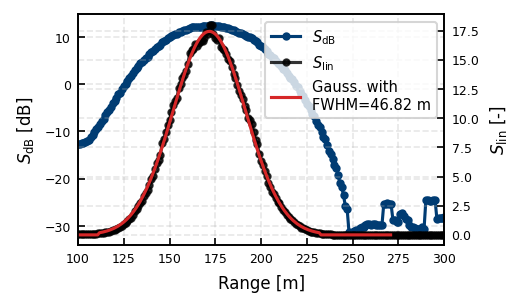

In [7]:

fig, ax= publication_figure(1/2, dpi =150, height = 2)
dsht_t['cnr'].plot(x='range',ax=ax, marker='.', label='Heligoland Lidar', color='C0')
ax.set(ylabel=r"$S_{\rm dB}$ [dB]", xlabel="Range [m]", xlim= (100,300), title = None)

axlin = ax.twinx()
axlin.plot([], [], marker='.', label=r'$S_{\rm dB}$', color='C0')
dsht_t_lin = 10**(dsht_t['cnr']/10)
axlin.plot(dsht_t['range'], dsht_t_lin, color='k', alpha=0.8, marker = '.', label = r'$S_{\rm lin}$')
axlin.set_ylabel(r"$S_{\rm lin}$ [-]")
Rmax, CNRmax, FWHM  = GaussianTruncatedPulse.fit_weighting_to_data(dsht_t_lin.range.values, dsht_t_lin.values)
Rmax, CNRmax, FWHM 

dr = np.arange(-100,100,1.0)
# pulse = GaussianTruncatedPulse(47).get_weighting(dr)
pulse = GaussianTruncatedPulse(FWHM).get_weighting(dr)*CNRmax
axlin.plot(dr + Rmax, pulse, label=f'Gauss. with \nFWHM={FWHM:.2f} m', color='tab:red')

axlin.legend(loc='upper right')
# ax.plot(dr + Rmax, 10*np.log10(pulse), label='Lidar Pulse Shape', color='tab:red')
# axlin.plot(dr + 173, pulse/pulse.max()*dsht_t_lin.max().values, label='Lidar Pulse Shape', color='C1')
# ax.plot(dr + 173, 10*np.log10(pulse/pulse.max()*dsht_t_lin.max().values), label='Lidar Pulse Shape', color='C1')
plt.savefig(savepath + 'HardTargetPulseShape_50m.pdf')


## Visualize the different lidar-water-range detection methods:
Following methods are possible:
|Method | Description |LSQ fit in which scale|
|----|---|---|
|LinSig |Sigmoid is defined in linear scale, linear prefactor in dB scale (exponential in linear)| linear scale|
|dBSig |Sigmoid is defined in linear scale, linear prefactor in dB scale (exponential in linear)| dB scale|
|Gra24|Method from Gramitzky et al 2024, everything is defined in dB scale (not correct for sigmoid scale)| dB scale|
|Gra25|Method from Gramitzky et al 2026, everything is defined in dB scale (not correct for sigmoid scale) - half the probe volume length| dB scale|
|Rot21|Method from Rott et al. 2022, no linear prefactor |dB scale|
|Convo|pulse convolution with fix truncated gaussian shape in linear scale| lin scale|
|dBConvo|pulse convolution with fix truncated gaussian shape in dB sacle| dB scale|
|Convo_pulsevar|pulse convolution with variable truncated gaussian shape| dB scale|
|LinConvo_pulsevar|pulse convolution with variable truncated gaussian shape| lin scale|


<div class="alert alert-block alert-info">
<b>Tip:</b> There are different inputs, which should be considered. The input CNR to the fitting function should be in dB scale</div>



[ 4.77090184e+02 -3.22297214e+01 -8.69569617e+00  5.01441692e-02
  1.42218319e-05]
first guess for middle range: 425
first_guess: [np.int32(425), np.float64(0.00044701284207000254), np.float64(0.15100801541641481), 0.01, 0.01]
bounds: Bounds(array([ 2.0e+02, -4.0e+01, -2.3e+01,  5.0e-04, -1.5e-02]), array([ 6.74e+02, -2.00e+01, -3.00e+00,  1.00e+00,  3.00e-02]))
First guess 0.00044701284207000254 not in bounds -40.0 - -20.0, clipping
First guess 0.15100801541641481 not in bounds -23.0 - -3.0, clipping
Using fit method: LSQ
[ 4.15291118e+02 -3.14297406e+01 -7.30195020e+00  4.15628768e-02
  9.61484732e-03]
first guess for middle range: 425
Had to switch to minimize for convolution fit method, due to fitting problems with curve fit and ODR
first_guess: [np.int32(425), 0.01, np.float64(-8.21), -32]
bounds: Bounds(array([ 2.0e+02, -1.5e-02, -2.2e+01, -4.0e+01]), array([ 6.74e+02,  3.00e-02,  0.00e+00, -2.50e+01]))
Using fit method: minimize
[ 4.14441157e+02  1.14697730e-02 -7.05274097e+00 -

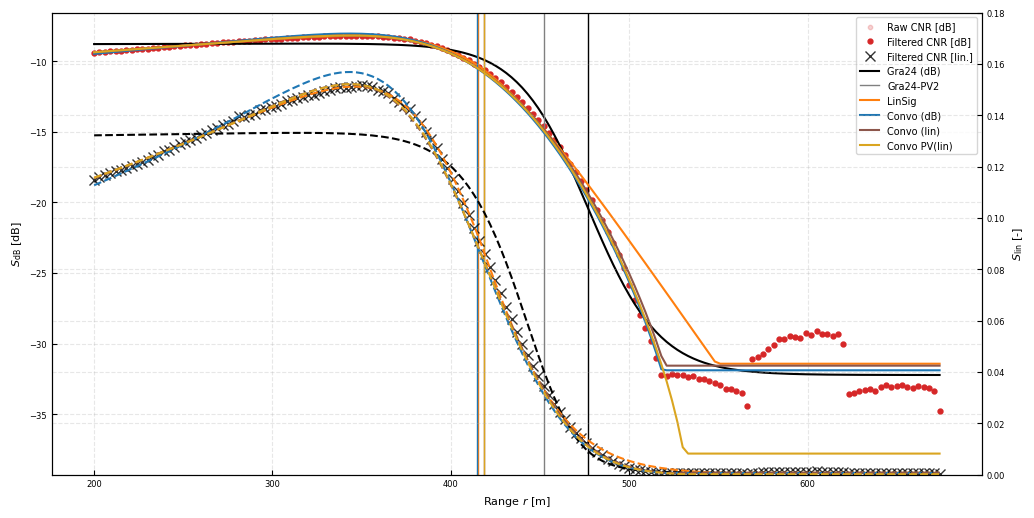

In [8]:
%matplotlib inline
from lidalign.SSC import inverse_sigmoid_Gra24, linear2db, db2linear
# fig, ax = publication_figure(1/2, dpi =250, height = 2.5)
fig, ax = plt.subplots(figsize = (12,6))
ds100_water = ds_100[-5].isel(time = -10).copy()
dsuse = ds100_water.copy()
L_rg = 94
pulse = GaussianTruncatedPulse(L_rg)
ax.scatter(dsuse['range'], dsuse['cnr'], label='Raw CNR [dB]', color='tab:red', s = 10, alpha = 0.2)
# dsuse['cnr'].plot(x='range',ax=ax, marker='.', label='Raw CNR [dB]', color='tab:red', markersize = 7, lw = 0, alpha = 0.2)



legend_entries = []
legend_names = []

axlin = ax.twinx()
dsuse_lin = 10**(dsuse['cnr']/10)


## normal sigmoid with linear
res = WaterRangeDetection(dsuse).get_water_range_from_cnr(func = 'Gra24', return_fit = True)
ax.plot(res.fit_data['range'], res.fit_data['data_db'].values, marker='.', label='Filtered CNR [dB]', color='tab:red', markersize = 7, lw = 0)
axlin.plot(res.fit_data['range'], res.fit_data['data_lin'], color='k', alpha=0.8, marker = 'x', label = r'$S_{\rm lin}$', markersize = 7, lw = 0)
ax.plot([],[], color='k', alpha=0.8, marker = 'x', label = 'Filtered CNR [lin.]', markersize = 7, lw = 0)
print(res.x)

linedb, = ax.plot(res.fit_data['range'], res.fit_data['fit_db'].values, label='Gra24 (dB)', color='k')
linelin, = axlin.plot(res.fit_data['range'], res.fit_data['fit_lin'].values, label='Gra24', color='k', ls = '--')
ax.axvline(res.r_water, color='k', lw=1, label=None)
ax.axvline(res.r_water-25, color='grey', lw=1, label='Gra24-PV2')

# improved sigmoid in linear scale
color = 'tab:orange'
res = WaterRangeDetection(dsuse, verbose = 2, pulse = pulse).get_water_range_from_cnr(func = 'LinSig', return_fit = True)
ax.plot(res.fit_data['range'], res.fit_data['fit_db'].values, label='LinSig', color=color)
axlin.plot(res.fit_data['range'], res.fit_data['fit_lin'].values, label='LinSig', color=color, ls = '--')
ax.axvline(res.r_water, color=color, lw=1, label=None)
print(res.x)

# Convolution in linear_scale
color = 'tab:blue'
res = WaterRangeDetection(dsuse, verbose = 2, pulse = pulse).get_water_range_from_cnr(func = 'Convo', return_fit = True, dist_guess =None)
ax.plot(res.fit_data['range'], res.fit_data['fit_db'].values, label='Convo (dB)', color=color)
axlin.plot(res.fit_data['range'], res.fit_data['fit_lin'].values, label='Convolution (lin)', color=color, ls = '--')
ax.axvline(res.r_water, color=color, label=None, lw = 1)
print(res.x)


# Convolution in linear_scale
color = 'tab:brown'
res = WaterRangeDetection(dsuse, verbose = 2, pulse = pulse).get_water_range_from_cnr(func = 'LinConvo', return_fit = True)
ax.plot(res.fit_data['range'], res.fit_data['fit_db'].values, label='Convo (lin)', color=color)
axlin.plot(res.fit_data['range'], res.fit_data['fit_lin'].values, label='Convolution (lin)', color=color, ls = '--')
ax.axvline(res.r_water, color=color, label=None, lw = 1)
print(res.x)


# convolution in linear scale with variable pulse length
color = 'goldenrod'
res = WaterRangeDetection(dsuse, verbose = 2, pulse = pulse).get_water_range_from_cnr(func = 'LinConvo_pulse', return_fit = True)
ax.plot(res.fit_data['range'], res.fit_data['fit_db'].values, label='Convo PV(lin)', color=color)
axlin.plot(res.fit_data['range'], res.fit_data['fit_lin'].values, label='Convolution  PV (lin)', color=color, ls = '--')
ax.axvline(res.r_water, color=color, label=None, lw = 1)
print(res.x)
# ax.plot(fitdata['range'], fitdata['fit'].values, label='Convolution (linear)', color='C2', ls = '--')



ax.set(title = None, ylabel = r'$S_{\rm dB}$ [dB]', xlabel = r'Range $r$ [m]')
axlin.set(ylabel = r'$S_{\rm lin}$ [-]')
ax.legend(loc = 'upper right')
axlin.set_ylim(0, 0.18)
plt.savefig(savepath + f'WaterRangeFittingMethods_{L_rg}m.pdf', bbox_inches='tight')


first guess for middle range: 419
first_guess: [np.int32(419), np.float64(0.0003908408957924021), np.float64(0.15734030945534866), 0.01, 0.01]
bounds: Bounds(array([ 2.0e+02, -4.0e+01, -2.3e+01,  5.0e-04, -1.5e-02]), array([ 6.74e+02, -2.00e+01, -3.00e+00,  1.00e+00,  3.00e-02]))
First guess 0.0003908408957924021 not in bounds -40.0 - -20.0, clipping
First guess 0.15734030945534866 not in bounds -23.0 - -3.0, clipping
Using fit method: LSQ
first guess for middle range: 419
Had to switch to minimize for convolution fit method, due to fitting problems with curve fit and ODR
first_guess: [np.int32(419), 0.01, np.float64(-8.0316), -32]
bounds: Bounds(array([ 2.0e+02, -1.5e-02, -2.2e+01, -4.0e+01]), array([ 6.74e+02,  3.00e-02,  0.00e+00, -2.50e+01]))
Using fit method: minimize


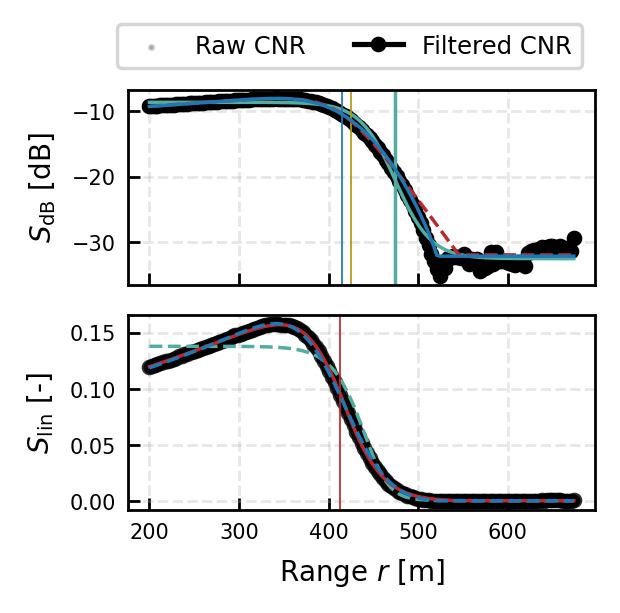

In [9]:
fig, [ax, axlin] = publication_figure(2/5, dpi =250, height = 2.5, nrows = 2, sharex = True)
ds100_water = ds_100[0].isel(time =100 ).copy()
dsuse = ds100_water.copy()
ax.scatter(dsuse['range'], dsuse['cnr'], label='Raw CNR', color='k', s = 1, alpha = 0.2)
# dsuse['cnr'].plot(x='range',ax=ax, marker='.', label='Raw CNR [dB]', color='tab:red', markersize = 7, lw = 0, alpha = 0.2)



legend_entries = []
legend_names = []

# axlin = ax.twinx()
dsuse_lin = 10**(dsuse['cnr']/10)


## normal sigmoid with linear
ret = WaterRangeDetection(dsuse).get_water_range_from_cnr(func = 'Gra24', return_fit = True)
ax.plot(ret.fit_data['range'], ret.fit_data['data_db'].values, label='Filtered CNR', marker = '.', color='k', markersize = 7)
axlin.plot(ret.fit_data['range'], ret.fit_data['data_lin'], color='k', alpha=0.8, marker = '.', label = r'$S_{\rm lin}$', markersize = 7, lw = 0)
# ax.plot([],[], color='k', alpha=0.8, marker = 'x', label = 'Filtered CNR [lin.]', markersize = 7, lw = 0)

linedb, = ax.plot(ret.fit_data['range'], ret.fit_data['fit_db'].values, color='#50ad9f', lw = 1) #, label='Gra24 (dB)'
linelin, = axlin.plot(ret.fit_data['range'], ret.fit_data['fit_lin'].values, color='#50ad9f', ls = '--', lw = 1) #, label='Gra24'
ax.axvline(ret.r_water, color='#50ad9f', lw=1, label=None)
ax.axvline(ret.r_water-50, color='#B3990E', lw=0.5)#, label='Gra24-PV2'


# improved sigmoid in linear scale
color = '#bc272d'
ret = WaterRangeDetection(dsuse, verbose = 2, pulse = GaussianTruncatedPulse(50)).get_water_range_from_cnr(func = 'LinSig', return_fit = True)
ax.plot(ret.fit_data['range'], ret.fit_data['fit_db'].values, color=color, lw = 1, ls = '--')#, label='LinSig'
axlin.plot(ret.fit_data['range'], ret.fit_data['fit_lin'].values, color=color, lw = 1) #, label='LinSig'
axlin.axvline(ret.r_water, color=color, lw=0.5, label=None)



# improved sigmoid in dB scale
# params, fitdata = WaterRangeDetection(dsuse, verbose = 2, pulse = GaussianTruncatedPulse(50)).get_water_range_from_cnr(func = 'LinSig', return_fit = True)
# ax.plot(fitdata['range'], fitdata['fit_db'].values, label='SSC (dB)', color='red')
# axlin.plot(fitdata['range'], fitdata['fit_lin'].values, label='SSC (dB)', color='red', ls = '--')
# ax.axvline(params, color='red', lw=1, label=None)

# legend_entries.append((linedb, linelin))
# legend_names.append('Gra24')


# # Convolution
# params, fitdata = WaterRangeDetection(dsuse, verbose = 2, pulse = GaussianTruncatedPulse(50)).get_water_range_from_cnr(func = 'convolution', return_fit = True)
# ax.plot(fitdata['range'], fitdata['fit_db'].values, label='Convo (dB)', color='C2')
# axlin.plot(fitdata['range'], fitdata['fit_lin'].values, label='Convolution (lin)', color='C2', ls = '--')
# ax.axvline(params, color='C2', ls = ':', label=None)


# Convolution in dB scale
color = 'tab:blue'
ret = WaterRangeDetection(dsuse, verbose = 2, pulse = GaussianTruncatedPulse(95)).get_water_range_from_cnr(func = 'LinConvo', return_fit = True, fit_method = 'LSQ')
ax.plot(ret.fit_data['range'], ret.fit_data['fit_db'].values, color=color, lw =1) #, label='Convo (dB)'
axlin.plot(ret.fit_data['range'], ret.fit_data['fit_lin'].values, color=color, ls = '--', lw =1) #, label='Convolution (lin)'
ax.axvline(ret.r_water, color=color, label=None, lw = 0.5)



# Convolution in linear_scale
# color = 'tab:blue'
# params, fitdata = WaterRangeDetection(dsuse, verbose = 2, pulse = GaussianTruncatedPulse(50)).get_water_range_from_cnr(func = 'convo_pulse', return_fit = True, use_linear_scale = False)
# ax.plot(fitdata['range'], fitdata['fit_db'].values, label='Convo PV(dB)', color=color)
# axlin.plot(fitdata['range'], fitdata['fit_lin'].values, label='Convolution (lin)', color=color, ls = '--')
# ax.axvline(params, color=color, label=None, lw = 1)

# ax.plot(fitdata['range'], fitdata['fit'].values, label='Convolution (linear)', color='C2', ls = '--')



ax.set(title = None, ylabel = r'$S_{\rm dB}$ [dB]')#, xlim = (300,600))
axlin.set(ylabel = r'$S_{\rm lin}$ [-]', xlabel = r'Range $r$ [m]')
ax.legend(loc = 'lower left', ncols = 3, bbox_to_anchor=(-0.05, 1.05))
# axlin.set_ylim(0, 0.08)
plt.tight_layout()
plt.savefig(savepath + 'WaterRangeFittingMethods_50m.pdf', bbox_inches='tight', pad_inches= 0)

#  for r in rgs]
# axf.errorbar(range_gates, means, yerr = stds, capsize = 3, marker = '.', lw = 1, c = '#50ad9f')#, label = r'Gra24'
# axf.errorbar(range_gates, means_cor, yerr = stds_cor, capsize = 3, marker = '.', c = '#B3990E', lw = 1) #,  label = r'Gra24-PV2'
# axf.errorbar(range_gates, means_lin, yerr = std_lin, capsize = 3, marker = 'x', lw = 1, c = '#bc272d')#, label = r'SSC(lin)'
# axf.errorbar(range_gates, means_conv, yerr = std_conv, capsize = 3, marker = 'x', lw = 1, c = 'tab:blue') #, label = r'Conv(dB)'


## View and filter measurement data

Let us first filter some of the data

#### CNR during the measurements

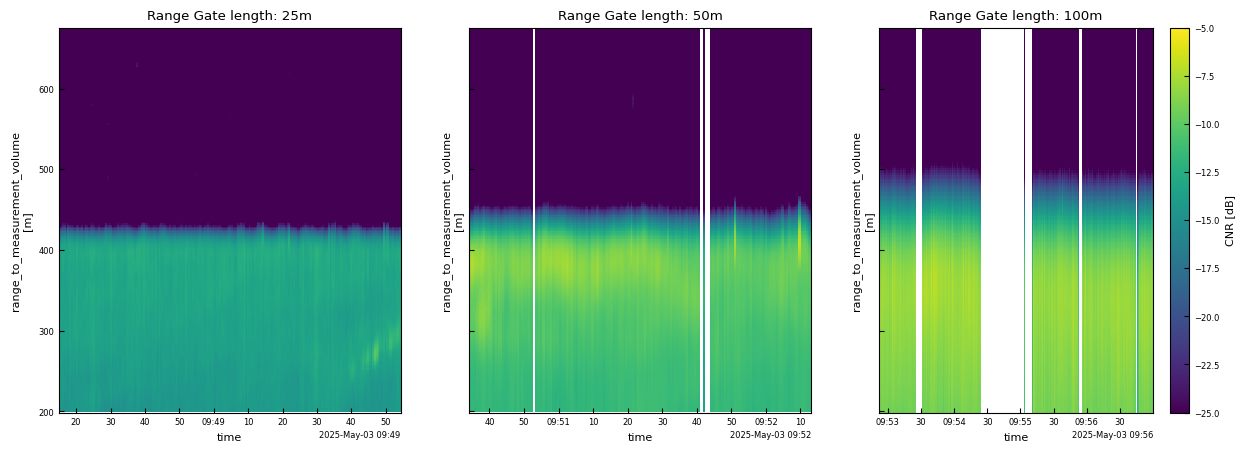

In [10]:
%matplotlib inline

fig, axes = plt.subplots(ncols=3, sharey=True, figsize=(15, 5))
rgs = ["25m", "50m", "100m"]
dsliste = []
for ax, ds, rage in zip(axes, [ds_25, ds_50, ds_100], rgs):
    dsa = xr.concat(ds, dim="time").isel(time=slice(50, None))

    # cb = dsa["cnr"].plot(ax=ax, x="time", vmin=-25, vmax=-5, add_colorbar=False, alpha = 0.5)

    dsa["cnr"] = dsa["cnr"].where(
        (dsa["cnr"].max(dim="range") < -5) & (dsa["cnr"].max(dim="range") > -14.5)
        & ((dsa["cnr"].max(dim="range") - dsa["cnr"].min(dim="range"))>15)
    )
    if rage != '25m':
        dsa['cnr'] = dsa['cnr'].where( dsa['cnr'].max(dim = 'range')>-12)

    cb = dsa["cnr"].plot(ax=ax, x="time", vmin=-25, vmax=-5, add_colorbar=False)
    ax.set(title=f"Range Gate length: {rage}")
    dsliste.append(dsa[['range','cnr','elevation','azimuth','time']])
plt.colorbar(cb, ax=axes[-1], label="CNR [dB]")


## Evaluation of staring results


In [11]:
figsavepath = savepath + 'EvalFigures/Starring'
import pathlib
pathlib.Path(figsavepath).mkdir(parents=True, exist_ok=True)    
# figsavepath ='' # to ignore plotting

In [12]:
from lidalign.SSC import SSC

distances = []
distances_linear = []
distances_db = []
distances_convolution = []
distances_convolution_pulsevar= []
distances_convolution_linear= []

for dsa, rg in zip(dsliste, rgs):
    
    # pulse = 

    # dsa = xr.concat(ds, dim="time").isel(time=slice(10, None))
    # dsa["cnr"] = dsa["cnr"].where(
    #     (dsa["cnr"].max(dim="range") < -5) & (dsa["cnr"].max(dim="range") > -15)
    # )
    dsa["cnr"] = dsa["cnr"].where(
        (dsa["cnr"].max(dim="range") < -5) & (dsa["cnr"].max(dim="range") > -15)
        & ((dsa["cnr"].max(dim="range") - dsa["cnr"].min(dim="range"))>15)
    )

    # original Method by Gramitzky et al. 2024 --> No CNR noise level considered, but it should be, as it brings a big improvement!
    ssl = SSC(dsa.copy()).get_all_water_ranges(func = 'Gra24', verbose = 0, cnr_noise_cut = None, saveplot = figsavepath)
    distances.append(ssl.distance_ds)

    # ssllin = SSL(dsa).get_all_water_ranges(use_linear_scale = False, verbose = 0, func = 'SSC_lin')
    # distances_linear.append(ssllin.distance_ds)
    ssllinsig = SSC(dsa).get_all_water_ranges(func = 'LinSig', cnr_noise_cut = -30, saveplot = figsavepath)
    distances_linear.append(ssllinsig.distance_ds)    

    # sslconv = SSL(dsa).get_all_water_ranges(func = 'dBSig')#, cnr_noise_cut = -30)
    # distances_db.append(sslconv.distance_ds)    

    sslconv = SSC(dsa).get_all_water_ranges(func = 'Convo', pulse = GaussianTruncatedPulse(float(rg.replace('m',''))), saveplot = figsavepath)
    distances_convolution.append(sslconv.distance_ds)

    sslconv = SSC(dsa).get_all_water_ranges(func = 'LinConvo', pulse = GaussianTruncatedPulse(float(rg.replace('m',''))), saveplot = figsavepath)
    distances_convolution_linear.append(sslconv.distance_ds)

    # sslconv = SSL(dsa).get_all_water_ranges(func = 'Convo_pulse', pulse = GaussianTruncatedPulse(float(rg.replace('m',''))))
    # distances_convolution_pulsevar.append(sslconv.distance_ds)


    


Obtaining lidar-water range:   0%|          | 0/196 [00:00<?, ?it/s]

Obtaining lidar-water range: 100%|██████████| 489/489 [03:29<00:00,  2.34it/s]


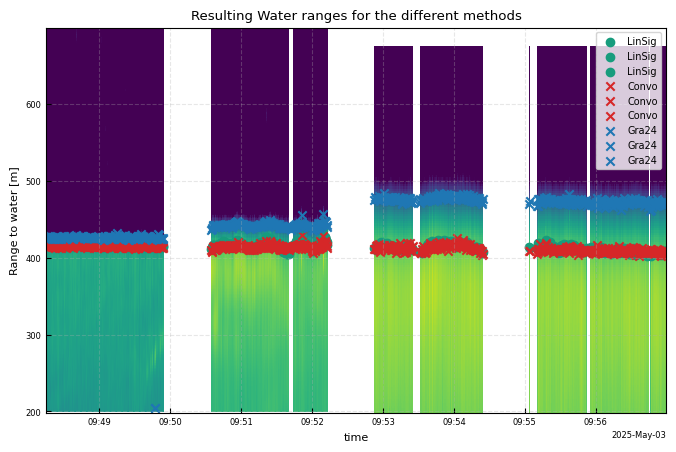

In [13]:
%matplotlib inline
fig, ax = plt.subplots()
for ds in dsliste:
    ax.pcolormesh(
        ds.time,
        ds.range,
        ds["cnr"].transpose(),
        vmin=-25,
        vmax=-5,
        shading="auto",
        cmap="viridis",
    )

for ds in distances_linear:
    ds.plot.scatter(ax=ax, y = 'water_range', marker="o", color="C1", label="LinSig")

for ds in distances_convolution:
    ds.plot.scatter(ax=ax, y = 'water_range', marker="x", color="tab:red", label="Convo")

for ds in distances:
    ds.plot.scatter(ax=ax, y = 'water_range', marker="x", color="tab:blue", label="Gra24")

# for ds in distances_convolution_linear:
#     ds.plot.scatter(ax=ax, y = 'water_range', marker="x", color="tab:orange", label="Convo linear")

ax.set(title="Resulting Water ranges for the different methods")
ax.legend(loc = 'upper right')

### Observe individual situations

first situation e.g. with bump in cnr curve (probably wave or similar? )

1
1
first guess for middle range: 416
first_guess: [np.int32(416), np.float64(0.0004819477976251271), np.float64(0.16109423543966536), 0.01, 0.01]
bounds: Bounds(array([ 2.0e+02, -4.0e+01, -2.3e+01,  5.0e-04, -1.5e-02]), array([ 6.98e+02, -2.00e+01, -3.00e+00,  1.00e+00,  3.00e-02]))
First guess 0.0004819477976251271 not in bounds -40.0 - -20.0, clipping
First guess 0.16109423543966536 not in bounds -23.0 - -3.0, clipping
Using fit method: LSQ
{'distance': np.float64(415.8301620086376), 'lower': np.float64(-30.453795724168195), 'upper': np.float64(-7.317315921386256), 'growth': np.float64(0.10313614356712594), 'linearfac': np.float64(0.0256114248928172)}


[Text(0, 0.5, 'CNR [dB]'), Text(0.5, 0, 'Range [m]')]

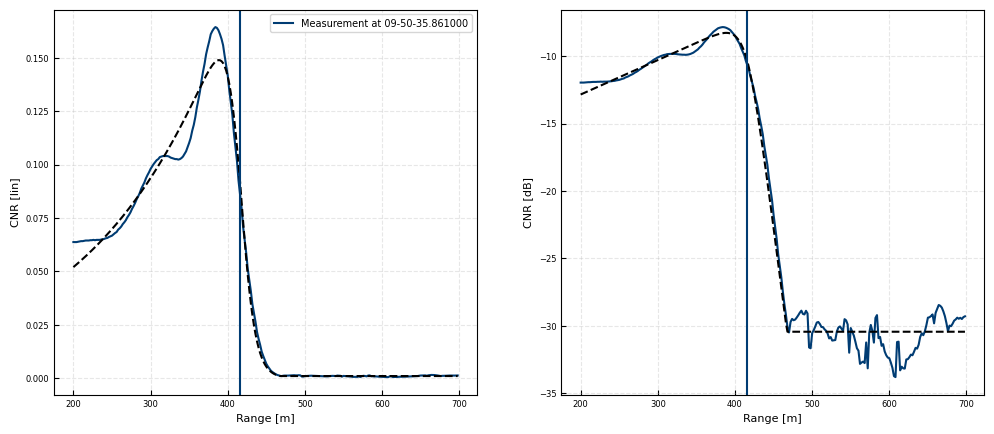

In [14]:
import pandas as pd
# example: bump in CNR
# dsa = dsliste[1].copy()
# ts = dsa.time[-7:-4]

# example: drop in retrieved dist:
# dsa = dsliste[0].copy()
# ts = dsa.time[-14:-13]

#example: 
# dsa = dsliste[-1].copy()
# ts = dsa.sel(time = slice("2025-05-03 09:53:40","2025-05-03 09:53:41")).time
# print(len(ts))

#example drop in obtained range: 
# dsa = dsliste[-1].copy()
# ts = dsa.sel(time = slice("2025-05-03 09:53:40","2025-05-03 09:53:41")).time
# print(len(ts))


#example step of rw: 
dsa = dsliste[-1].copy()
rg = 100
ts = dsa.sel(time = slice("2025-05-03 09:56:02.5","2025-05-03 09:56:03.5")).time


# example of CNR
# dsa = dsliste[0].copy()
# rg = 25
# ts = dsa.sel(time = slice("2025-05-03 09:48:17","2025-05-03 09:48:17.5")).time

# example of CNR high due to waves?
# dsa = dsliste[1].copy()
# rg = 50
# ts = dsa.sel(time = slice("2025-05-03 09:51:51.0","2025-05-03 09:51:51.5")).time


# dsa = dsliste[1].copy()
# rg = 50
# ts = dsa.sel(time = slice("2025-05-03 09:50:56.0","2025-05-03 09:50:56.5")).time

dsa = dsliste[1].copy()
rg = 50
ts = dsa.sel(time = slice("2025-05-03 09:50:35.5","2025-05-03 09:50:36.0")).time



print(len(ts))



print(len(ts))
fig, [ax, axdb] = plt.subplots(ncols = 2, sharex = True, figsize = (12,5))
for t in ts:
    dst = dsa.sel(time = t)#.dropna('range')
    if np.sum(~np.isnan(dst['cnr'].values))<10:
        print("Skipping time ", pd.to_datetime(t.values))
        continue
    
    fitresult = WaterRangeDetection(dst, verbose = 3, pulse = GaussianTruncatedPulse(rg)).get_water_range_from_cnr(return_fit = True,func = 'LinSig')
    # fitresult = WaterRangeDetection(dst, verbose = 3, pulse = GaussianTruncatedPulse(rg)).get_water_range_from_cnr(return_fit = True,func = 'Gra24')#, lin_fac_guess=0.01, dist_guess = 410)
    if not fitresult.success:
        print('Nothing, will skip')
        continue
    print(fitresult.params)
    ax.plot(dst['range'], fitresult.fit_data['data_lin'], label = f'Measurement at {pd.to_datetime(t.values).strftime("%H-%M-%S.%f")}')
    ax.plot(dst['range'], fitresult.fit_data['fit_lin'], ls = '--', c= 'k')
    ax.axvline(fitresult.r_water)

    axdb.plot(dst['range'], fitresult.fit_data['data_db'], label = f'Measurement at {pd.to_datetime(t.values).strftime("%H-%M-%S.%f")}')
    axdb.plot(dst['range'], fitresult.fit_data['fit_db'], ls = '--', c= 'k')
    axdb.axvline(fitresult.r_water)


# ax.set(xlim = (430,480))
ax.legend()
ax.set(ylabel = 'CNR [lin]' , xlabel = 'Range [m]')
axdb.set(ylabel = 'CNR [dB]' , xlabel = 'Range [m]')

## Comparison of methods from starring alone

### Variation of range with time due to water level? 

we see some variation of the retrieved data with time. This might be caused by the fact, that the water level is varying. 

### Paper plot: Range dependency

In [15]:
# --------------------------- remove single outlier -------------------------- #
distances[0]['water_range'].loc[dict(time = '2025-05-03T09:49:46.889000000')] = np.nan

C:\Users\Paul\AppData\Local\Temp\ipykernel_35168\1221037321.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\Paul\AppData\Local\Temp\ipykernel_35168\1221037321.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


first guess for middle range: 419
first_guess: [np.int32(419), np.float64(0.0003908408957924021), np.float64(0.15734030945534866), 0.01, 0.01]
bounds: Bounds(array([ 2.0e+02, -4.0e+01, -2.3e+01,  5.0e-04, -1.5e-02]), array([ 6.74e+02, -2.00e+01, -3.00e+00,  1.00e+00,  3.00e-02]))
First guess 0.0003908408957924021 not in bounds -40.0 - -20.0, clipping
First guess 0.15734030945534866 not in bounds -23.0 - -3.0, clipping
Using fit method: LSQ
first guess for middle range: 419
Had to switch to minimize for convolution fit method, due to fitting problems with curve fit and ODR
first_guess: [np.int32(419), 0.01, np.float64(-8.0316), -32]
bounds: Bounds(array([ 2.0e+02, -1.5e-02, -2.2e+01, -4.0e+01]), array([ 6.74e+02,  3.00e-02,  0.00e+00, -2.50e+01]))
Using fit method: minimize
[<xarray.DataArray 'water_range' ()> Size: 8B
array(414.97932439), <xarray.DataArray 'water_range' ()> Size: 8B
array(414.24352866), <xarray.DataArray 'water_range' ()> Size: 8B
array(410.93542505)]
[<xarray.DataArra

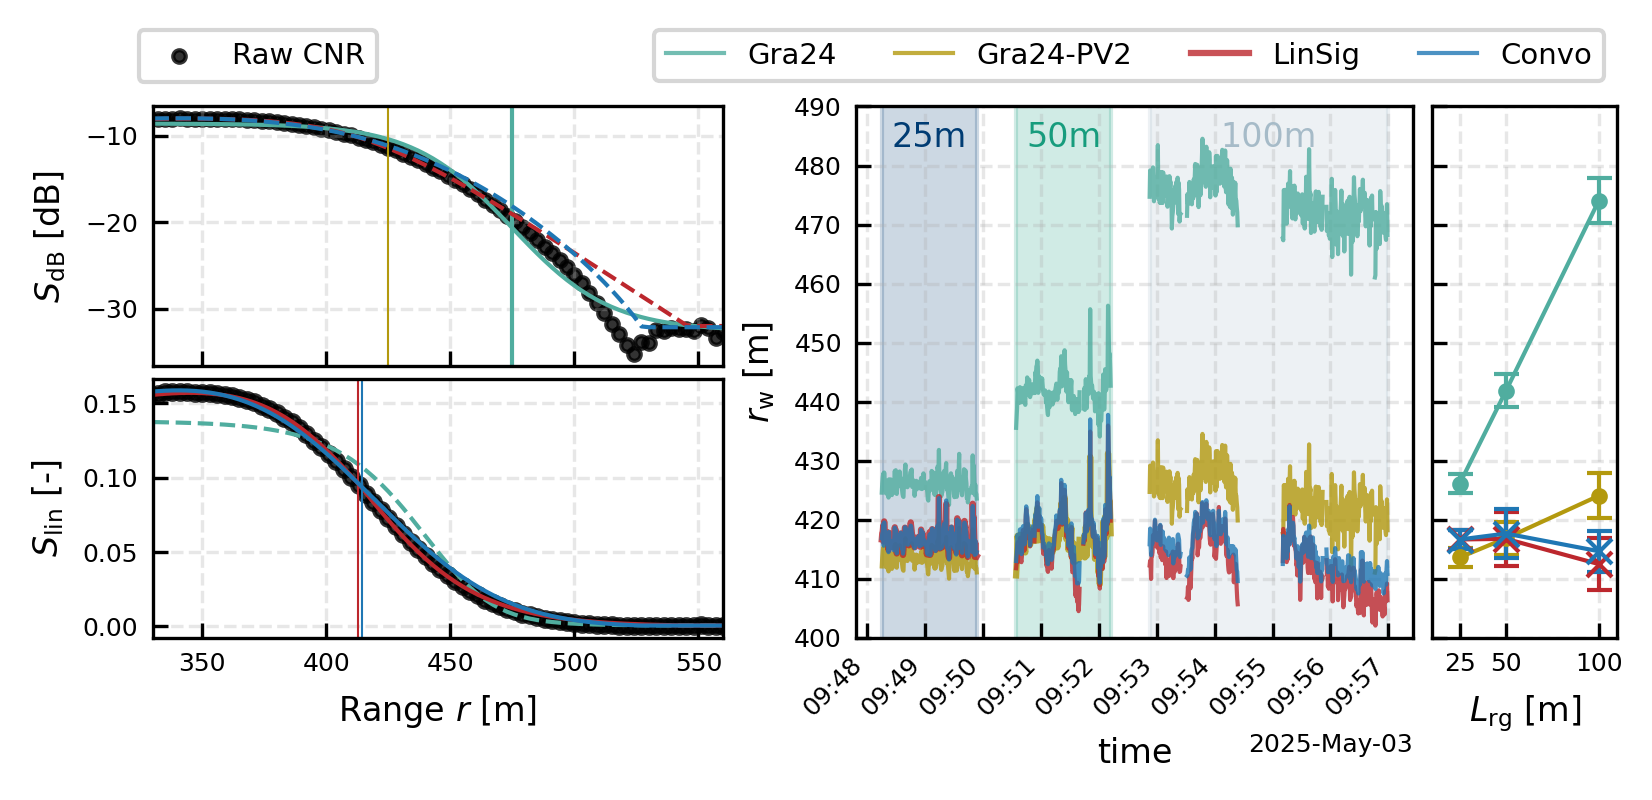

In [39]:
%matplotlib inline
import numpy as np
import scipy
from matplotlib.gridspec import GridSpec



# Create figure
fig = publication_figure(1, height = 2.3, fig_only = True) #plt.subplots(ncols = 2, sharey = True, figsize = (12,5))
outer = GridSpec(
    1, 2,
    width_ratios=[1.5, 2],
    wspace=0.2   # spacing BETWEEN left and right blocks
)
gs_left = outer[0].subgridspec(2, 1, hspace=0.05)  # Left block with 2 rows


gs_right = outer[1].subgridspec(
    1, 2,
    width_ratios=[3, 1],
    wspace=0.05,   # spacing BETWEEN the two right subplots
    hspace= 0.1
)
ax = fig.add_subplot(gs_right[0, 0])  # Span both rows in the second column
axf = fig.add_subplot(gs_right[0, 1], sharey = ax)  # First column spanning both rows


ax.set(ylim = (400,490))
# plt.subplots_adjust(hspace=0)
# plt.tight_layout()
means = []
stds = []

means_cor = []
stds_cor = []

means_lin = []
std_lin = []
means_conv = []
std_conv = []

means_conv_linear = []
std_conv_linear = []

color_cycle = iter(plt.rcParams['axes.prop_cycle'].by_key()['color'])

handles = []
i=0

for rg, distds, dislins, disconv, disconv_linear in zip( rgs, distances, distances_linear,  distances_convolution, distances_convolution_linear):
    color = next(color_cycle)
    
    
    maxdiff = 5
    maxdiff = 100
    where= np.abs(np.diff(distds['water_range'], append = 0))<maxdiff

    # (distds['water_range']-float(rg.replace('m',''))/2).where(where).plot(ax = ax, label = r"dB scale: $L_{\rm rg}$" + f" {rg}", c = 'k')
    alpha = 0.8
    distds['water_range'].where(where).plot(ax = ax, label = r"Gra24" if i==0 else None, c = '#50ad9f', lw = 1, alpha = alpha)


    (distds['water_range']-float(rg.replace('m',''))/2).where(where).plot(ax = ax, label = r"Gra24-PV2" if i==0 else None, c = '#B3990E', lw= 1 if i!=1 else 1.5, alpha = alpha)
    dislins['water_range'].where(where).plot(ax = ax, label = r"LinSig" if i==0 else None, ls = '-', c = '#bc272d', lw= 1.5 if i==0 else 1, alpha = alpha)
    # disdb['water_range'].where(where).plot(ax = ax, label = r"DB2 scale: $L_{\rm rg}$" + f" {rg}", ls = '--', c = 'tab:red')
    # disconv['water_range'].where(where).plot(ax = ax, label = r"Convo (dB)" if i==0 else None, ls = '-', c = 'tab:orange', lw= 1, alpha = alpha)
    disconv_linear['water_range'].where(where).plot(ax = ax, label = r"Convo" if i==0 else None, lw= 1, c = 'tab:blue', alpha = alpha)

    # disconv_pulsevar['water_range'].where(where).plot(ax = ax, label = r"Conv : $L_{\rm rg}$" + f" {rg}", ls = '-', c = 'tab:red')

    
    # disconv['water_range'].where(disconv['water_range']>400).plot(ax = ax, label = r"Convolution: $L_{\rm rg}$" + f" {rg}", ls = '--', c = 'tab:red')
    # disconv['water_range'].where(disconv['water_range']>400).plot(ax = ax, label = r"Convolution: $L_{\rm rg}$" + f" {rg}", ls = '--', c = 'tab:red')
    # disconv_pulsevar['water_range'].where(disconv_pulsevar['water_range']>400).plot(ax = ax, label = r"Convolution Pulse Var: $L_{\rm rg}$" + f" {rg}", ls = '--', c = 'tab:red')

    means.append( distds['water_range'].where(where).mean())
    stds.append(distds['water_range'].where(where).std())

    means_cor.append( (distds['water_range']-float(rg.replace('m',''))/2).where(where).mean())
    stds_cor.append((distds['water_range']-float(rg.replace('m',''))/2).where(where).std())

    means_lin.append( dislins['water_range'].where(where).mean())
    std_lin.append(dislins['water_range'].where(where).std())

    means_conv.append( disconv['water_range'].where(where).mean())
    std_conv.append(disconv['water_range'].where(where).std())

    means_conv_linear.append( disconv_linear['water_range'].where(where).mean())
    std_conv_linear.append(disconv_linear['water_range'].where(where).std())


    t0, t1 = distds.time[0].values, distds.time[-1].values
    ax.fill_between([t0,t1], [350,350], [500,500], color = color, alpha = 0.2)
    ax.text(t0 + (t1 - t0)/2, 482, f'{rg}', color = color, ha = 'center', va = 'bottom')
    i+=1
    # axf.errorbar(float(rg.replace('m','')), distds['water_range'].mean(), 
    #              yerr = )

range_gates = [float(r.replace('m','')) for r in rgs]
axf.errorbar(range_gates, means, yerr = stds, capsize = 3, marker = '.', lw = 1, c = '#50ad9f')#, label = r'Gra24'
axf.errorbar(range_gates, means_cor, yerr = stds_cor, capsize = 3, marker = '.', c = '#B3990E', lw = 1) #,  label = r'Gra24-PV2'
axf.errorbar(range_gates, means_lin, yerr = std_lin, capsize = 3, marker = 'x', lw = 1, c = '#bc272d')#, label = r'SSC(lin)'
# axf.errorbar(range_gates, means_conv, yerr = std_conv, capsize = 3, marker = 'x', lw = 1, c = 'tab:orange') #, label = r'Conv(dB)'
axf.errorbar(range_gates, means_conv_linear, yerr = std_conv_linear, capsize = 3, marker = 'x', lw = 1, c = 'tab:blue') #, label = r'Conv(dB)'

# print('Gra24: ', means)
# axf.plot(range_gates, means_lin, marker = 'o', lw = 2, label = r'$\mu$ New Method', c = 'tab:orange')

ax.set(ylabel = r'$r_{\rm w}$ [m]')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
axf.set(xlabel = r'$L_{\rm rg}$ [m]')
res = scipy.stats.linregress(range_gates, means)
ri = np.arange(0,100)


# axf.plot(ri, ri * res.slope + res.intercept, ls = '--', c = 'k', zorder = -2, label = rf'$y = {res.slope:.2f}x$'+'\n'+f'+${res.intercept:.1f}$')


t = pd.date_range('2025-05-03 09:48','2025-05-03 09:57', freq = '1min')
# ax.axhline(406, label='Mean Elevation', color='tab:blue')

elevation = -0.91

# water_interpolated = water_level_lidar.reindex(water_level_lidar.index.union(t)).interpolate(method = 'time').reindex(t)
# height_error = 0.20 ## approximately higher than
# R = (water_interpolated-height_error)/ np.sin(np.deg2rad(elevation))
# R_min = (water_interpolated-height_error-0.1)/ np.sin(np.deg2rad(elevation))
# R_max = (water_interpolated-height_error+0.1)/ np.sin(np.deg2rad(elevation))
# ax.plot(t, R, c = 'tab:red', zorder = 10, ls = '--', lw = 1)
# ax.fill_between(t, R_min.values[:,0], R_max.values[:,0], color = 'grey', alpha = 0.1, label = r'$\Delta H$ = 0.1m')

# ax.legend()
plt.tight_layout()
ax.legend(ncols = 4, loc = 'lower left', bbox_to_anchor = (-0.39,1.02), frameon=True)
axf.set(xlim = (10,110))
axf.set_xticks([25,50,100])
# axf.legend(loc = 'upper left')

# --------------------------- Plot left: CNR Signal -------------------------- #

# fig, [ax, axlin] = publication_figure(2/5, dpi =250, height = 2.5, nrows = 2, sharex = True)

axdb = fig.add_subplot(gs_left[0, 0])  # First row, first column
axlin = fig.add_subplot(gs_left[1, 0], sharex = axdb)  # Second row, first column
ds100_water = ds_100[0].isel(time =100 ).copy()
dsuse = ds100_water.copy()
axdb.scatter(dsuse['range'], dsuse['cnr'], label='Raw CNR', color='k', alpha=0.8, marker = '.',)
# dsuse['cnr'].plot(x='range',ax=ax, marker='.', label='Raw CNR [dB]', color='tab:red', markersize = 7, lw = 0, alpha = 0.2)



legend_entries = []
legend_names = []

# axlin = ax.twinx()
dsuse_lin = 10**(dsuse['cnr']/10)


## normal sigmoid with linear
ret = WaterRangeDetection(dsuse).get_water_range_from_cnr(func = 'Gra24', return_fit = True, cnr_noise_cut = None)
# ax.plot(fitdata['range'], fitdata['data_db'].values, label='Filtered CNR', marker = '.', color='k', markersize = 7)
axlin.plot(ret.fit_data['range'], ret.fit_data['data_lin'], color='k', alpha=0.8, marker = '.', label = r'$S_{\rm lin}$', markersize = 7, lw = 0)
# ax.plot([],[], color='k', alpha=0.8, marker = 'x', label = 'Filtered CNR [lin.]', markersize = 7, lw = 0)

linedb, = axdb.plot(ret.fit_data['range'], ret.fit_data['fit_db'].values, color='#50ad9f', lw = 1) #, label='Gra24 (dB)'
linelin, = axlin.plot(ret.fit_data['range'], ret.fit_data['fit_lin'].values, color='#50ad9f', ls = '--', lw = 1) #, label='Gra24'
axdb.axvline(ret.r_water, color='#50ad9f', lw=1, label=None)
axdb.axvline(ret.r_water-50, color='#B3990E', lw=0.5)#, label='Gra24-PV2'


# improved sigmoid in linear scale
color = '#bc272d'
ret = WaterRangeDetection(dsuse, verbose = 2, pulse = GaussianTruncatedPulse(50)).get_water_range_from_cnr(func = 'LinSig', return_fit = True)
axdb.plot(ret.fit_data['range'], ret.fit_data['fit_db'].values, color=color, lw = 1, ls = '--')#, label='LinSig'
axlin.plot(ret.fit_data['range'], ret.fit_data['fit_lin'].values, color=color, lw = 1) #, label='LinSig'
axlin.axvline(ret.r_water, color=color, lw=0.5, label=None)



# improved sigmoid in dB scale
# params, fitdata = WaterRangeDetection(dsuse, verbose = 2, pulse = GaussianTruncatedPulse(50)).get_water_range_from_cnr(func = 'LinSig', return_fit = True)
# ax.plot(fitdata['range'], fitdata['fit_db'].values, label='SSC (dB)', color='red')
# axlin.plot(fitdata['range'], fitdata['fit_lin'].values, label='SSC (dB)', color='red', ls = '--')
# ax.axvline(params, color='red', lw=1, label=None)

# legend_entries.append((linedb, linelin))
# legend_names.append('Gra24')


# # Convolution
# params, fitdata = WaterRangeDetection(dsuse, verbose = 2, pulse = GaussianTruncatedPulse(50)).get_water_range_from_cnr(func = 'convolution', return_fit = True)
# ax.plot(fitdata['range'], fitdata['fit_db'].values, label='Convo (dB)', color='C2')
# axlin.plot(fitdata['range'], fitdata['fit_lin'].values, label='Convolution (lin)', color='C2', ls = '--')
# ax.axvline(params, color='C2', ls = ':', label=None)


# Convolution in dB Scale
if False:
    color = 'tab:orange'
    ret = WaterRangeDetection(dsuse, verbose = 2, pulse = GaussianTruncatedPulse(100)).get_water_range_from_cnr(func = 'Convo', return_fit = True)
    axdb.plot(ret.fit_data['range'], ret.fit_data['fit_db'].values, color=color, lw =1) #, label='Convo (dB)'
    axlin.plot(ret.fit_data['range'], ret.fit_data['fit_lin'].values, color=color, ls = '--', lw =1) #, label='Convolution (lin)'
    axdb.axvline(ret.r_water, color=color, label=None, lw = 0.5)


# Convolution in linear_scale
color = 'tab:blue'
ret = WaterRangeDetection(dsuse, verbose = 2, pulse = GaussianTruncatedPulse(100)).get_water_range_from_cnr(func = 'LinConvo', return_fit = True)
axdb.plot(ret.fit_data['range'], ret.fit_data['fit_db'].values, color=color, ls = '--', lw =1) #, label='Convo (dB)'
axlin.plot(ret.fit_data['range'], ret.fit_data['fit_lin'].values, color=color, lw =1) #, label='Convolution (lin)'
axlin.axvline(ret.r_water, color=color, label=None, lw = 0.5)



# Convolution in linear_scale
# color = 'tab:blue'
# params, fitdata = WaterRangeDetection(dsuse, verbose = 2, pulse = GaussianTruncatedPulse(50)).get_water_range_from_cnr(func = 'convo_pulse', return_fit = True, use_linear_scale = False)
# ax.plot(fitdata['range'], fitdata['fit_db'].values, label='Convo PV(dB)', color=color)
# axlin.plot(fitdata['range'], fitdata['fit_lin'].values, label='Convolution (lin)', color=color, ls = '--')
# ax.axvline(params, color=color, label=None, lw = 1)

# ax.plot(fitdata['range'], fitdata['fit'].values, label='Convolution (linear)', color='C2', ls = '--')



# water correction
elevation = -0.91
# water_interpolated = water_level_lidar.reindex(water_level_lidar.index.union(t)).interpolate(method = 'time').reindex(t)

# height_error = 0.1
# R = (water_interpolated-height_error)/ np.sin(np.deg2rad(elevation))
# R_min = (water_interpolated-height_error-0.1)/ np.sin(np.deg2rad(elevation))
# R_max = (water_interpolated-height_error+0.1)/ np.sin(np.deg2rad(elevation))
# ax.plot(t, R, c = 'k', label = r'Expected Range', zorder = 1)
# ax.fill_between(t, R_min.values[:,0], R_max.values[:,0], color = 'k', alpha = 0.1, label = r'$\Delta H$ = 0.1m')




axdb.set(title = None, ylabel = r'$S_{\rm dB}$ [dB]', xlim = (330,560))
axlin.set(ylabel = r'$S_{\rm lin}$ [-]', xlabel = r'Range $r$ [m]')
axdb.legend(loc = 'lower left', ncols = 3, bbox_to_anchor=(-0.05, 1.04), frameon=True)
# axlin.set_ylim(0, 0.08)
# plt.tight_layout()
plt.setp(axdb.get_xticklabels(), visible=False)
plt.setp(axf.get_yticklabels(), visible=False)
# ax.set(xlabel = '')
plt.tight_layout()
plt.savefig(savepath + 'WaterRangeFittingMethods_50m.pdf', bbox_inches='tight', pad_inches= 0)


print(means_conv)
print(means_lin)

It looks like, the Pulse width of the Convo method is too high. If a shorter pulse with is chosen, this might help to reduce the error. We find supporting arguments when looking at the return signal strenght of CNR for a measurement against a hard target. You will find this in the the section [Hard target pulse form](20_CornerScanTest_Heligoland.ipynb#Hard-Target-Pulse-shape-investigation) of the other notebook (for Test (b))


### statistics

In [35]:

diffs = [means_conv_linear[i] - means_lin[i] for i in range(len(means_conv))]
diffs

[<xarray.DataArray 'water_range' ()> Size: 8B
 array(-0.00853444),
 <xarray.DataArray 'water_range' ()> Size: 8B
 array(0.89446075),
 <xarray.DataArray 'water_range' ()> Size: 8B
 array(2.18448621)]

In [36]:
std_lin

[<xarray.DataArray 'water_range' ()> Size: 8B
 array(1.64865703),
 <xarray.DataArray 'water_range' ()> Size: 8B
 array(4.56352929),
 <xarray.DataArray 'water_range' ()> Size: 8B
 array(4.41510995)]

## Appendix

### Averaged CNR curves 

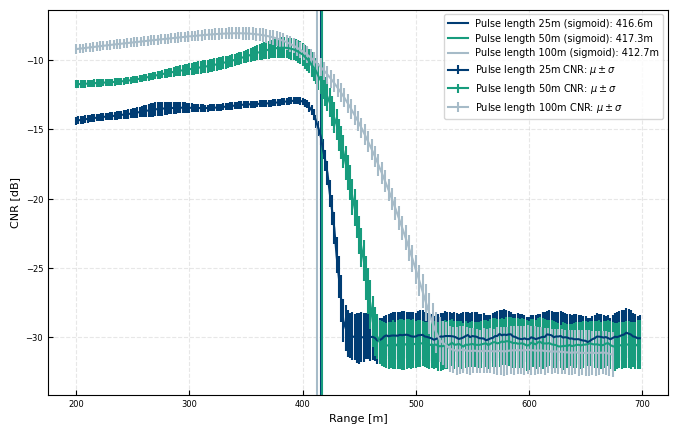

In [37]:

from lidalign.SSC import SSC, WaterRangeDetection

colors = iter(plt.rcParams["axes.prop_cycle"].by_key()["color"])
fig, ax = plt.subplots()

for dsa, rg in zip(dsliste, rgs):

    
    mean = dsa[["cnr"]].mean(dim="time")
    ret = WaterRangeDetection(mean).get_water_range_from_cnr(func = 'LinSig', fit_method ='LSQ')
    ax.axvline(ret.r_water, c=next(colors), label = f"Pulse length {rg} (sigmoid): {ret.r_water:.1f}m")
    c = ax.errorbar(
        dsa.range,
        mean["cnr"],
        dsa["cnr"].std(dim="time"),
        label=fr"Pulse length {rg} CNR: $\mu \pm \sigma$ ",
    )
    
ax.legend()
ax.set(ylabel="CNR [dB]", xlabel="Range [m]")
ax.grid(alpha=0.3, ls="--")


### Range fit with normal dB scale:

- large deviations between the different range gate lengths

Explanation:
- Fitting in dB range values the noise values (-30dB) the same as the actual measurements. The noise variations in dB vary much more then the actual signal. 

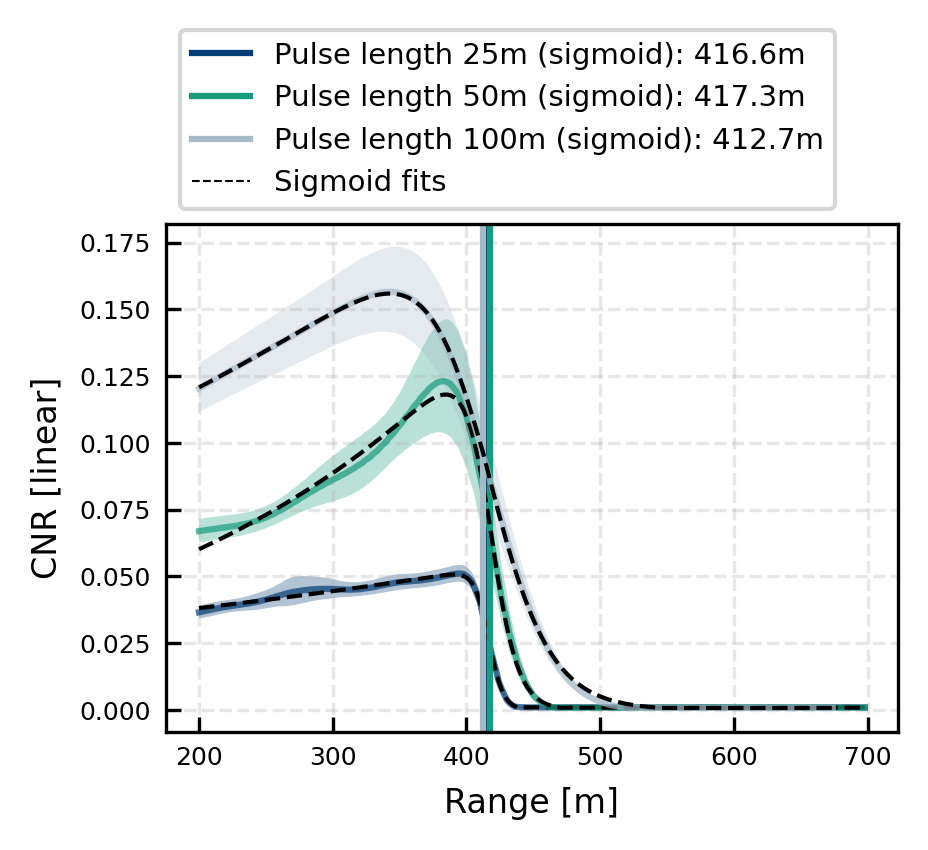

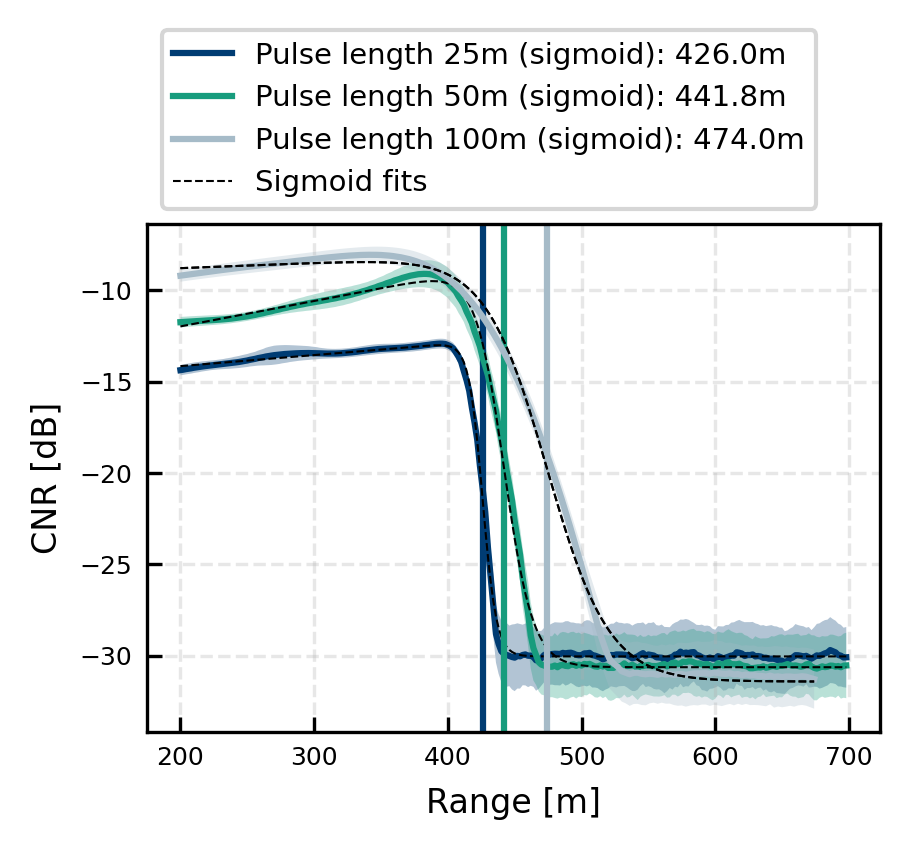

In [39]:

from lidalign.SSC import SSC, WaterRangeDetection

colors = iter(plt.rcParams["axes.prop_cycle"].by_key()["color"])
import scipy
figl, axl = publication_figure(1/2, height = 2.2)
fig, ax = publication_figure(1/2, height = 2.2)
rangs = []

for dsa, rg in zip(dsliste, rgs):
    c = next(colors)
    # ----------------------------- plot in db scale ----------------------------- #
    mean = dsa[["cnr"]].copy().mean(dim="time")
    ret = WaterRangeDetection(mean).get_water_range_from_cnr(return_fit = True, func = 'Gra24')
    ax.axvline(ret.r_water, c=c, label = f"Pulse length {rg} (sigmoid): {ret.r_water:.1f}m")
    ax.plot(dsa.range, mean['cnr'])
    std =  dsa["cnr"].std(dim="time") 
    ax.fill_between(dsa.range, mean['cnr'] - std, mean['cnr']+std, alpha = 0.3)
    
    ax.plot(dsa.range, ret.fit_data['fit_db'], c = 'k', ls = '--', lw = 0.5)
    rangs.append(ret.r_water)

    # ------------------------- plot in linear scale also ------------------------ #
    mean = dsa[["cnr"]].copy().mean(dim="time")
    ret2 = WaterRangeDetection(mean).get_water_range_from_cnr(return_fit = True, func = 'LinSig')
    axl.axvline(ret2.r_water, c=c, label = f"Pulse length {rg} (sigmoid): {ret2.r_water:.1f}m")
    # mean = dsal[["cnr"]].mean(dim="time")
    axl.plot(ret2.fit_data.range, ret2.fit_data['data_lin'], alpha = 0.7)
    axl.fill_between(dsa.range, db2linear(mean['cnr'] - std), db2linear(mean['cnr']+std), alpha = 0.3)
    
    axl.plot(ret2.fit_data.range, ret2.fit_data['fit_lin'], c = 'k', ls = '--', lw = 1)
    
    # ax.plot(dsa.range, fit, c = 'k', ls = '--', lw = 1)



ax.plot(dsa.range, ret.fit_data['fit_db'], c = 'k', ls = '--', label = 'Sigmoid fits', lw = 0.5)
ax.legend(loc = 'lower left', bbox_to_anchor = (0,1))
ax.set(ylabel="CNR [dB]", xlabel="Range [m]")
ax.grid(alpha=0.3, ls="--")


axl.plot([],[], c = 'k', ls = '--', label = 'Sigmoid fits', lw = 0.5)
axl.legend(loc = 'lower left', bbox_to_anchor = (0,1))
axl.set(ylabel="CNR [linear]", xlabel="Range [m]")
axl.grid(alpha=0.3, ls="--")

figl.savefig(savepath + 'WaterRangeFittingMethods_LinearScale.pdf', bbox_inches='tight')

### Range fit with linear scale

Much more consistent between the different range gate lengths. 

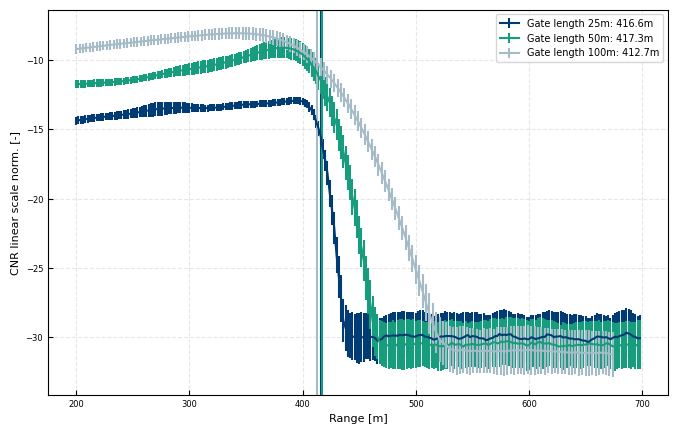

In [40]:

colors = iter(plt.rcParams["axes.prop_cycle"].by_key()["color"])
fig, ax = plt.subplots()
rangs_linear = []

for dsa, rg in zip(dsliste, rgs):
    # dsa = xr.concat(ds, dim="time").isel(time=slice(50, None)).copy()
    # dsa["cnr"] = dsa["cnr"].where(
    #     (dsa["cnr"].max(dim="range") < -5) & (dsa["cnr"].max(dim="range") > -15)
    # )

    dsa["cnr"] = dsa["cnr"].where(
        (dsa["cnr"].max(dim="range") < -5) & (dsa["cnr"].max(dim="range") > -15)
        & ((dsa["cnr"].max(dim="range") - dsa["cnr"].min(dim="range"))>15)
    )
    
    # dsa['cnr'] = 10**(dsa['cnr']/10)

    # dsa['cnr'] = dsa['cnr']/dsa['cnr'].max(dim = 'range')
    # mean = dsa[["cnr"]].mean(dim="time")
    # rang = WaterRangeDetection(mean, verbose = 1).get_water_range_from_cnr(low_cnr_bounds=[0,0.5],
    #                                      high_cnr_bounds=[0, 1], 
    #                                      min_cnr=0, 
    #                                      min_cnr_diff = 0.02,
    #                                      cnr_hard_target = 1, use_bounds = False)


    mean = dsa[["cnr"]].mean(dim="time")
    ret2 = WaterRangeDetection(mean, verbose = 1).get_water_range_from_cnr(func = 'LinSig')


    ax.axvline(ret2.r_water, c=next(colors))
    c = ax.errorbar(
        dsa.range,
        mean["cnr"],
        dsa["cnr"].std(dim="time"),
        label=f"Gate length {rg}: {ret2.r_water:.1f}m",
    )
    rangs_linear.append(ret2.r_water)
ax.legend()
ax.set(ylabel="CNR linear scale norm. [-]", xlabel="Range [m]")
ax.grid(alpha=0.3, ls="--")


## Some Playing with the data

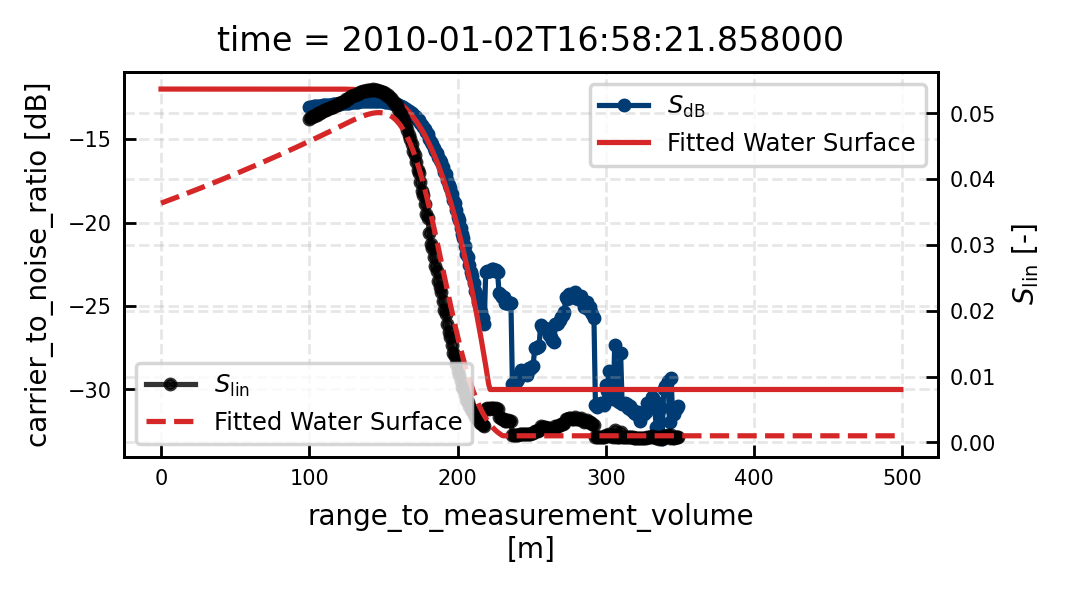

In [41]:
fig, ax = publication_figure(2/3, dpi =250, height = 2)
ds50_water['cnr'].plot(x='range', marker='.', label=r'$S_{\rm dB}$', color='C0')


axlin = ax.twinx()
dswater_lin = 10**(ds50_water['cnr']/10)
axlin.plot(dswater_lin['range'], dswater_lin, color='k', alpha=0.8, marker = '.', label = r'$S_{\rm lin}$')
axlin.set_ylabel(r"$S_{\rm lin}$ [-]")

# ax.set(title = None, ylabel=r"$S_{\rm dB}$ [dB]", xlabel="Range [m]"), xlim= (100,300))

dr = np.arange(0,500,1)
fitdata = WaterRangeDetection.model_cnr_signal_convolution(dr, 180, 0, -12, GaussianTruncatedPulse(FWHM), cnr_noise = -30, return_dB=True)
ax.plot(dr, fitdata, label='Fitted Water Surface', color='tab:red')

fitdata = WaterRangeDetection.model_cnr_signal_convolution(dr, 190, 0.01, -12.5, GaussianTruncatedPulse(FWHM), cnr_noise = -30, return_dB=False)
axlin.plot(dr, fitdata, label='Fitted Water Surface', color='tab:red', ls = '--')
ax.legend()
axlin.legend(loc = 'lower left')

first guess for middle range: 182
Had to switch to minimize for convolution fit method, due to fitting problems with curve fit and ODR
first_guess: [np.int32(182), 0.01, np.float64(-12.71), -32, 50]
bounds: Bounds(array([ 1.0e+02, -1.5e-02, -2.2e+01, -4.0e+01,  4.0e+01]), array([ 3.49e+02,  3.00e-02,  0.00e+00, -2.50e+01,  5.50e+01]))
Using fit method: minimize
My Params:
{'distance': np.float64(182.9999999805309), 'linearfac': np.float64(0.014416892061842271), 'upper': np.float64(-11.984910157499861), 'noise': np.float64(-27.159347194380572), 'FWHM': np.float64(46.021145139319216)}
first guess for middle range: 182
Had to switch to minimize for convolution fit method, due to fitting problems with curve fit and ODR
first_guess: [np.int32(182), 0.01, np.float64(-12.71), -32]
bounds: Bounds(array([ 1.0e+02, -1.5e-02, -2.2e+01, -4.0e+01]), array([ 3.49e+02,  3.00e-02,  0.00e+00, -2.50e+01]))
Using fit method: minimize
My Params:
{'distance': np.float64(182.55618673144286), 'linearfac': np

[(0.0, 0.1)]

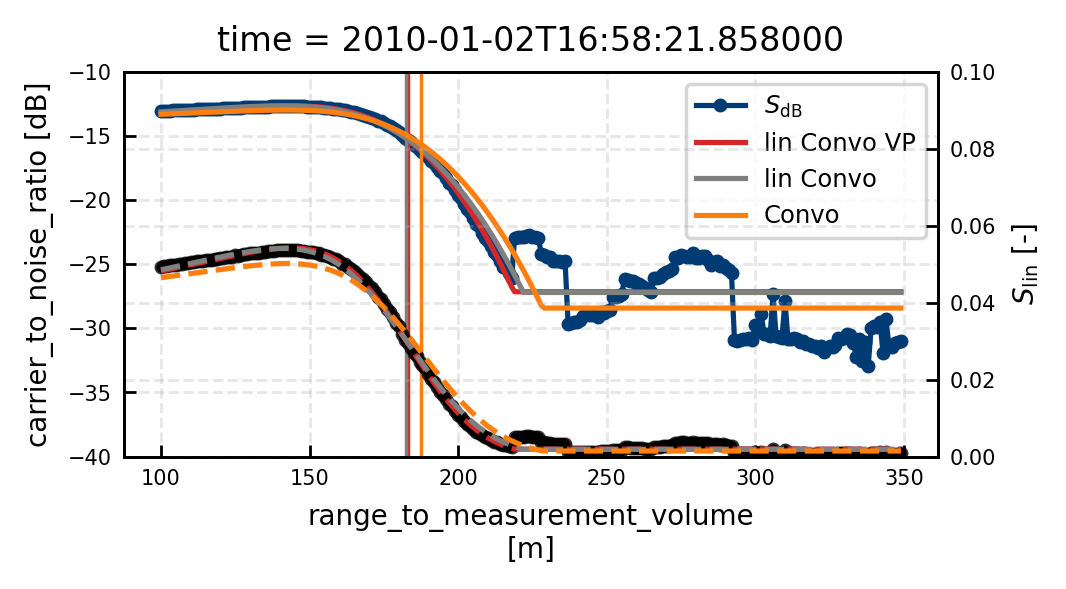

In [42]:
%matplotlib inline
fig, ax = publication_figure(2/3, dpi =250, height = 2)
ds50_water['cnr'].plot(x='range', marker='.', label=r'$S_{\rm dB}$', color='C0', ax = ax)


axlin = ax.twinx()
dswater_lin = 10**(ds50_water['cnr']/10)
axlin.plot(dswater_lin['range'], dswater_lin, color='k', alpha=0.8, marker = '.', label = r'$S_{\rm lin}$')
axlin.set_ylabel(r"$S_{\rm lin}$ [-]")

# ax.set(title = None, ylabel=r"$S_{\rm dB}$ [dB]", xlabel="Range [m]"), xlim= (100,300))

dr = np.arange(0,500,1)
# fitdata = WaterRangeDetection.model_cnr_signal_convolution(dr, 180, 0, -12, GaussianTruncatedPulse(FWHM), cnr_noise = -30, return_dB=True)
# ax.plot(dr, fitdata, label='Fitted Water Surface', color='tab:red')

# fitdata = WaterRangeDetection.model_cnr_signal_convolution(dr, 190, 0.01, -12.5, GaussianTruncatedPulse(FWHM), cnr_noise = -30, return_dB=False,)
# axlin.plot(dr, fitdata, label='Fitted Water Surface', color='tab:blue', ls = '--')
# ax.legend()
# axlin.legend(loc = 'lower left')

# params,residuals, fitdata  = WaterRangeDetection(ds50_water, verbose = 2, pulse = GaussianTruncatedPulse(50)).get_water_range_from_cnr(func = 'convolution', return_fit = True)
ret = WaterRangeDetection(ds50_water, verbose = 2, pulse = GaussianTruncatedPulse(50)).get_water_range_from_cnr(func = 'LinConvo_pulse', return_fit = True)
ax.plot(ret.fit_data['range'], ret.fit_data['fit_db'].values, label='lin Convo VP', color='tab:red')
axlin.plot(ret.fit_data['range'], ret.fit_data['fit_lin'].values, label='lin Convo', color='tab:red', ls = '--')
ax.axvline(ret.r_water, color='tab:red', lw=1, label=None)
print('My Params:')
print(ret.params)


ret = WaterRangeDetection(ds50_water, verbose = 2, pulse = GaussianTruncatedPulse(50)).get_water_range_from_cnr(func = 'LinConvo', return_fit = True)
ax.plot(ret.fit_data['range'], ret.fit_data['fit_db'].values, label='lin Convo', color='grey')
axlin.plot(ret.fit_data['range'], ret.fit_data['fit_lin'].values, label='lin Convo', color='grey', ls = '--')
ax.axvline(ret.r_water, color='grey', lw=1, label=None)
print('My Params:')
print(ret.params)


ret = WaterRangeDetection(ds50_water, verbose = 2, pulse = GaussianTruncatedPulse(50)).get_water_range_from_cnr(func = 'Convo', return_fit = True)
ax.plot(ret.fit_data['range'], ret.fit_data['fit_db'].values, label='Convo', color='tab:orange')
axlin.plot(ret.fit_data['range'], ret.fit_data['fit_lin'].values, label='Convo', color='tab:orange', ls = '--')
ax.axvline(ret.r_water, color='tab:orange', lw=1, label=None)
ax.legend()
print(ret.params)
ax.set(ylim = (-40,-10))
axlin.set(ylim = (0,0.1))

Error: 0.001973304678035978


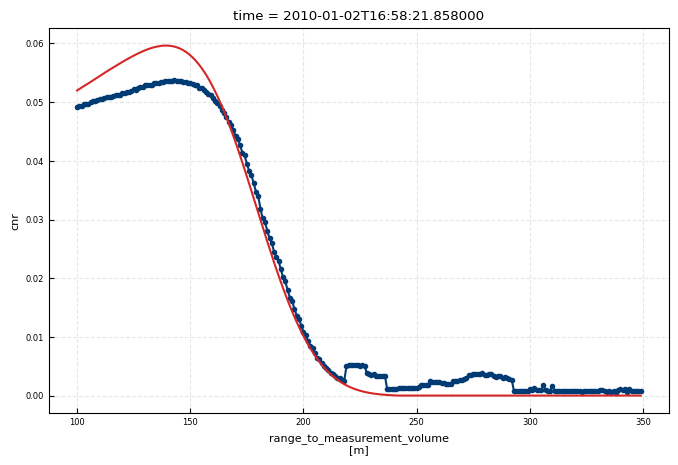

In [43]:

dswater_lin = ds50_water.copy()
dswater_lin['cnr'] = 10**(dswater_lin['cnr']/10)
params = (178, 0.02, -11.3, -30)
# params = (190, 0.02, -11.3, -30)
pulse = GaussianTruncatedPulse(50)
error = WaterRangeDetection.convolution_fit_error(params, *(dswater_lin, pulse, True) )
print(f"Error: {error}")
R_water = params[0]
cnr_slope = params[1]
cnr_offset = params[2]
cnr_noise = params[3]

r= dswater_lin['range'].values
fig, ax = plt.subplots()
dswater_lin['cnr'].plot(x='range', marker='.', label=r'$S_{\rm lin}$', color='C0', ax = ax)
model = WaterRangeDetection.model_cnr_signal_convolution(r, R_water, cnr_slope, cnr_offset, pulse, cnr_noise = -np.inf, return_dB=False)
ax.plot(r, model, label='Model', color='tab:red')

## Correction suggestion from Convo to Gra24 - similar to Gra24-PV2

We tried to find some correction factor (similar to Gra24-PV2) but it seems, the correction factor is dependend on the CNR level.

Vary the cnr_offset value to see variations also in the detected ranges

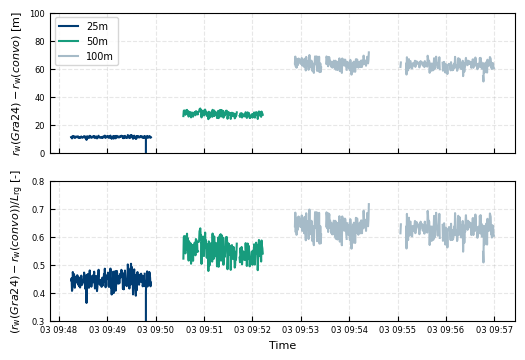

In [56]:
fig, [ax, axr] = plt.subplots(nrows = 2, sharex = True, figsize = (6,4))
for rg,dgra24, dconvo in zip(rgs, distances, distances_convolution):
    diff = dgra24['water_range'] - dconvo['water_range']
    ax.plot(dgra24.time, diff, label = f'{rg}')
    axr.plot(dgra24.time, diff/float(rg.replace('m','')), label = f'{rg}')


ax.set(ylabel = r'$r_{\rm w}(Gra24) - r_{\rm w} (convo)$ [m]', ylim = (0,100))
axr.set(ylabel = r'$(r_{\rm w}(Gra24) - r_{\rm w} (convo))/ L_{\rm rg}$ [-]', xlabel = 'Time' ,ylim = (0.3,0.8))

ax.legend()

Is this backed up by numerical analysis? 

[Text(0.5, 0, 'Range [m]'),
 Text(0, 0.5, 'CNR [dB]'),
 Text(0.5, 1.0, 'CNR Signal Simulation and Fitting, \nTrue Range = 300m, Slope = 0.0, Offset = -5dB, Noise floor = -30dB')]

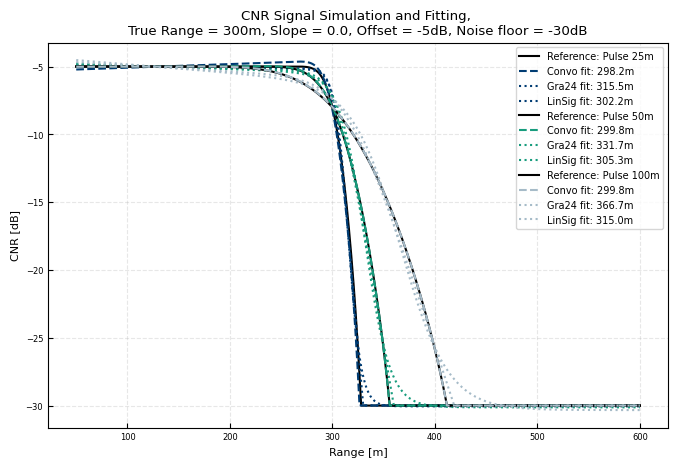

In [57]:
fig, ax = plt.subplots()
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
r = np.arange(50,600,0.1)
R = 300
cnr_slope = 0.0
cnr_offset = -5
cnr_noise = -30
for rg, c  in zip([25,50,100], colors):
    L = rg
    pulse = GaussianTruncatedPulse(L)
    model = WaterRangeDetection.model_cnr_signal_convolution(r, R, cnr_slope, cnr_offset, pulse, cnr_noise, return_dB=True)
    
    ax.plot(r, model, color='k', label = f'Reference: Pulse {L}m')
    data_db = xr.DataArray( data = model,
                        dims = ['range'],
                        coords = {'range': r}
                        )
    _ds = xr.Dataset({'cnr': data_db})

    ret = WaterRangeDetection(_ds, pulse = pulse).get_water_range_from_cnr(func = 'Convo', return_fit = True, cnr_noise_cut=-30, cnr_noise_first_guess=-30)
    ax.plot(ret.fit_data['range'], ret.fit_data['fit_db'], ls = '--', color=c, label = f'Convo fit: {ret.r_water:.1f}m')

    ret = WaterRangeDetection(_ds, pulse = pulse).get_water_range_from_cnr(func = 'Gra24', return_fit = True)
    ax.plot(ret.fit_data['range'], ret.fit_data['fit_db'], ls = ':', color=c, label = f'Gra24 fit: {ret.r_water:.1f}m')
    ret = WaterRangeDetection(_ds, pulse = pulse).get_water_range_from_cnr(func = 'dBSig', return_fit = True)
    ax.plot(ret.fit_data['range'], ret.fit_data['fit_db'], ls = ':', color=c, label = f'LinSig fit: {ret.r_water:.1f}m')

ax.legend()
ax.set(xlabel = 'Range [m]', ylabel = 'CNR [dB]', title = f'CNR Signal Simulation and Fitting, \nTrue Range = {R}m, Slope = {cnr_slope}, Offset = {cnr_offset}dB, Noise floor = {cnr_noise}dB')
